In [1]:
# ============================================================
# Cell 1 : Imports & Configuration
# ============================================================

import os
import random
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms

from torch.cuda.amp import autocast, GradScaler

from tqdm.auto import tqdm

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Speed Optimizations
# -----------------------------
torch.backends.cudnn.benchmark = True

# -----------------------------
# Dataset Paths
# -----------------------------
# REAL_DIR = Path(
#     "/kaggle/input/datasets/arshsefarsh/diff-group-11-dsai/Real/Real"
# )

# FAKE_DIR = Path(
#     "/kaggle/input/datasets/arshsefarsh/diff-group-11-dsai/SDv21_DS0.7/SDv21_DS0.7"
# )
REAL_DIR = Path(
    "/kaggle/input/datasets/philosopher0808/real-vs-ai-generated-faces-dataset/data_source/data_source/ffhq"
)

FAKE_DIR = Path(
    "/kaggle/input/datasets/mohannadaymansalah/stable-diffusion-dataaaaaaaaa"
)

# -----------------------------
# Extra Real Dataset (CelebA)
# Modern real photos → fixes HD misclassification
# Attach: jessicali9530/celeba-dataset on Kaggle
# -----------------------------
REAL_DIR_CELEBA = Path(
    "/kaggle/input/datasets/jessicali9530/celeba-dataset"
)
INCLUDE_CELEBA = REAL_DIR_CELEBA.exists()

# Stage 3 — HD fine-tuning
EPOCHS_STAGE3  = 3
LR_STAGE3      = 5e-6
MAX_CELEBA     = 8000   # cap to keep class balance

# -----------------------------
# Training Configuration
# -----------------------------
IMG_SIZE = 224

BATCH_SIZE = 128

NUM_WORKERS = 4

EPOCHS_STAGE1 = 3
EPOCHS_STAGE2 = 7

LR_STAGE1 = 3e-4
LR_STAGE2 = 1e-5

WEIGHT_DECAY = 1e-4

MODEL_NAME = "mobilenet_v3_large"

MODEL_SAVE_PATH = "/kaggle/working/mobilenetv3_best.pth"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("Device :", DEVICE)
print("GPU    :", torch.cuda.get_device_name(0))
print("=" * 60)

# -----------------------------
# Dataset Size
# -----------------------------
# Set to None to use ALL images.
#
# Examples:
#
# 10000 -> uses 10K Real + 10K Fake
#
# 15000 -> uses 15K Real + 15K Fake
#
# None -> uses every image
#
IMAGES_PER_CLASS = 15000

# -----------------------------
# DataLoader
# -----------------------------
PIN_MEMORY = True
PERSISTENT_WORKERS = True

# -----------------------------
# Mixed Precision
# -----------------------------
scaler = GradScaler()

print("\nConfiguration")
print("----------------------")
print(f"Image Size        : {IMG_SIZE}")
print(f"Batch Size        : {BATCH_SIZE}")
print(f"Stage 1 Epochs    : {EPOCHS_STAGE1}")
print(f"Stage 2 Epochs    : {EPOCHS_STAGE2}")
print(f"Images/Class      : {IMAGES_PER_CLASS}")
print(f"Mixed Precision   : Enabled")

Device : cuda
GPU    : Tesla T4

Configuration
----------------------
Image Size        : 224
Batch Size        : 128
Stage 1 Epochs    : 3
Stage 2 Epochs    : 7
Images/Class      : 15000
Mixed Precision   : Enabled


/tmp/ipykernel_58/1755532409.py:134: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [2]:
# CELL 1: Install RetinaFace face detector
import subprocess, sys

result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "retina-face", "-q"],
    capture_output=True, text=True, timeout=120
)
if result.returncode != 0:
    print("[INFO] retina-face not installed. Enable internet in Kaggle Settings -> Internet -> ON and re-run.")
    print("[INFO] Face detection will fall back to center-crop automatically.")


In [3]:
# CELL 2: Face Cropping and Alignment Preprocessor
import numpy as np
from PIL import Image

try:
    from retinaface import RetinaFace
    RETINA_AVAILABLE = True
except ImportError:
    RETINA_AVAILABLE = False
    print("WARNING: retina-face not installed — falling back to center crop.")

def crop_and_align_face(image_pil: Image.Image) -> Image.Image:
    """
    Detects faces using RetinaFace, crops the first detected face and resizes
    to 224x224. Falls back to center crop if RetinaFace is unavailable.
    """
    if RETINA_AVAILABLE:
        try:
            img_arr = np.array(image_pil)
            faces = RetinaFace.detect_faces(img_arr)
            if isinstance(faces, dict) and len(faces) > 0:
                face_id = list(faces.keys())[0]
                x1, y1, x2, y2 = faces[face_id]["facial_area"]
                return image_pil.crop((x1, y1, x2, y2)).resize(
                    (224, 224), Image.Resampling.LANCZOS
                )
        except Exception:
            pass

    w, h = image_pil.size
    crop_size = min(w, h)
    left = (w - crop_size) // 2
    top  = (h - crop_size) // 2
    return image_pil.crop(
        (left, top, left + crop_size, top + crop_size)
    ).resize((224, 224), Image.Resampling.LANCZOS)


In [4]:
# ============================================================
# Cell 2 : Build Dataset DataFrame
# ============================================================

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp"
)


def get_image_paths(folder):
    """Recursively collect all image paths."""
    paths = []

    for ext in VALID_EXTENSIONS:
        paths.extend(folder.rglob(f"*{ext}"))
        paths.extend(folder.rglob(f"*{ext.upper()}"))

    return sorted(paths)


print("Loading image paths...")

real_images = get_image_paths(REAL_DIR)
fake_images = get_image_paths(FAKE_DIR)

print(f"Found {len(real_images):,} Real images (FFHQ)")
print(f"Found {len(fake_images):,} Fake images (Stable Diffusion)")

# Add CelebA real faces if attached
if INCLUDE_CELEBA:
    celeba_imgs = get_image_paths(REAL_DIR_CELEBA)
    random.shuffle(celeba_imgs)
    celeba_imgs = celeba_imgs[:MAX_CELEBA]
    real_images = real_images + celeba_imgs
    print(f"Added   {len(celeba_imgs):,} Real images (CelebA HD)")
    print(f"Total Real: {len(real_images):,}")
else:
    print("⚠ CelebA not found — attach jessicali9530/celeba-dataset on Kaggle")


# ---------------------------------------------------
# Optional sampling
# ---------------------------------------------------
if IMAGES_PER_CLASS is not None:

    n_real = min(IMAGES_PER_CLASS, len(real_images))
    n_fake = min(IMAGES_PER_CLASS, len(fake_images))

    random.shuffle(real_images)
    random.shuffle(fake_images)

    real_images = real_images[:n_real]
    fake_images = fake_images[:n_fake]


print("\nUsing")

print(f"Real : {len(real_images):,}")
print(f"Fake : {len(fake_images):,}")


# ---------------------------------------------------
# Create DataFrame
# label:
# 0 -> Real
# 1 -> Fake
# ---------------------------------------------------

real_df = pd.DataFrame({
    "filepath": [str(p) for p in real_images],
    "label": 0
})

fake_df = pd.DataFrame({
    "filepath": [str(p) for p in fake_images],
    "label": 1
})

df = pd.concat(
    [real_df, fake_df],
    ignore_index=True
)

# Shuffle dataset
df = df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print("\nDataset Summary")
print("----------------------------")
print(df["label"].value_counts())

print("\nTotal Images :", len(df))

display(df.head())

Loading image paths...
Found 70,000 Real images (FFHQ)
Found 9,001 Fake images (Stable Diffusion)
Added   8,000 Real images (CelebA HD)
Total Real: 78,000

Using
Real : 15,000
Fake : 9,001

Dataset Summary
----------------------------
label
0    15000
1     9001
Name: count, dtype: int64

Total Images : 24001


,filepath,label
0,/kaggle/input/datasets/mohannadaymansalah/stab...,1
1,/kaggle/input/datasets/mohannadaymansalah/stab...,1
2,/kaggle/input/datasets/philosopher0808/real-vs...,0
3,/kaggle/input/datasets/mohannadaymansalah/stab...,1
4,/kaggle/input/datasets/philosopher0808/real-vs...,0


In [5]:
# ============================================================
# Cell 3 : Train / Validation / Test Split
# ============================================================

# First split:
# 80% Train
# 20% Temp

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED,
)

# Second split:
# Temp (20%) -> Validation (10%) + Test (10%)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
)

print("=" * 50)
print("Dataset Split")
print("=" * 50)

print(f"Train      : {len(train_df):,}")
print(f"Validation : {len(val_df):,}")
print(f"Test        : {len(test_df):,}")

print("\nTrain Distribution")
print(train_df.label.value_counts().sort_index())

print("\nValidation Distribution")
print(val_df.label.value_counts().sort_index())

print("\nTest Distribution")
print(test_df.label.value_counts().sort_index())

# Reset indices (important for Dataset class)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

Dataset Split
Train      : 19,200
Validation : 2,400
Test        : 2,401

Train Distribution
label
0    12000
1     7200
Name: count, dtype: int64

Validation Distribution
label
0    1500
1     900
Name: count, dtype: int64

Test Distribution
label
0    1500
1     901
Name: count, dtype: int64


In [6]:
# ============================================================
# Cell 4 : Dataset, Transforms & DataLoaders
# ============================================================

from torchvision import transforms
from PIL import ImageFilter
import random

# ----------------------------
# Gaussian Noise Transform
# ----------------------------
class AddGaussianNoise:
    def __init__(self, mean=0., std=0.03):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std + self.mean


# ----------------------------
# JPEG Compression Transform
# ----------------------------
class JPEGCompression:
    def __init__(self, quality=(40,95)):
        self.quality = quality

    def __call__(self, img):
        from io import BytesIO
        buffer = BytesIO()
        q = random.randint(self.quality[0], self.quality[1])
        img.save(buffer, format="JPEG", quality=q)
        buffer.seek(0)
        return Image.open(buffer).convert("RGB")




# ----------------------------
# Channel Shift Transform
# Randomly scales each RGB channel independently
# Teaches model that AI faces under any colour tint are still fake
# ----------------------------
class ChannelShift:
    def __init__(self, shift_range=0.30):
        self.shift_range = shift_range

    def __call__(self, img):
        import numpy as np
        arr = np.array(img).astype(np.float32)
        for c in range(3):
            factor = 1.0 + random.uniform(-self.shift_range, self.shift_range)
            arr[:, :, c] = np.clip(arr[:, :, c] * factor, 0, 255)
        return Image.fromarray(arr.astype(np.uint8))

train_transform = transforms.Compose([

    transforms.RandomResizedCrop(
        IMG_SIZE,
        scale=(0.8,1.0)
    ),

    transforms.RandomHorizontalFlip(),

    transforms.ColorJitter(
        brightness=0.40,
        contrast=0.40,
        saturation=0.40,
        hue=0.15
    ),

    transforms.RandomApply([
        ChannelShift(shift_range=0.30)
    ], p=0.50),

    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=3)
    ], p=0.30),

    transforms.RandomApply([
        JPEGCompression()
    ], p=0.40),

    transforms.ToTensor(),

    transforms.RandomApply([
        AddGaussianNoise(0.,0.03)
    ], p=0.40),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# -----------------------------
# Validation/Test Transform
# -----------------------------
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# Custom Dataset
# ============================================================

class ImageDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.iloc[idx]["filepath"]
        label = int(self.df.iloc[idx]["label"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# ============================================================
# Build Dataset Objects
# ============================================================

train_dataset = ImageDataset(
    train_df,
    transform=train_transform
)

val_dataset = ImageDataset(
    val_df,
    transform=val_transform
)

test_dataset = ImageDataset(
    test_df,
    transform=val_transform
)


# ============================================================
# DataLoaders
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS
)


print("=" * 60)
print("DataLoader Ready")
print("=" * 60)

print(f"Train Images : {len(train_dataset):,}")
print(f"Val Images   : {len(val_dataset):,}")
print(f"Test Images  : {len(test_dataset):,}")

print(f"\nTrain Batches : {len(train_loader)}")
print(f"Val Batches   : {len(val_loader)}")
print(f"Test Batches  : {len(test_loader)}")


# ------------------------------------------------------------
# Quick sanity check
# ------------------------------------------------------------

images, labels = next(iter(train_loader))

print("\nBatch Shape :", images.shape)
print("Labels Shape:", labels.shape)
print("Tensor Type :", images.dtype)

DataLoader Ready
Train Images : 19,200
Val Images   : 2,400
Test Images  : 2,401

Train Batches : 150
Val Batches   : 19
Test Batches  : 19

Batch Shape : torch.Size([128, 3, 224, 224])
Labels Shape: torch.Size([128])
Tensor Type : torch.float32


In [7]:
# ============================================================
# Cell 5 : Build MobileNetV3-Large
# ============================================================

from torchvision.models import (
    mobilenet_v3_large,
    MobileNet_V3_Large_Weights
)

# ------------------------------------------------------------
# Load ImageNet Pretrained Model
# ------------------------------------------------------------

weights = MobileNet_V3_Large_Weights.DEFAULT

model = mobilenet_v3_large(weights=weights)

print(model.classifier)

# ------------------------------------------------------------
# Freeze Entire Backbone
# ------------------------------------------------------------

for param in model.features.parameters():
    param.requires_grad = False

# ------------------------------------------------------------
# Replace Classification Head
# ------------------------------------------------------------

in_features = model.classifier[-1].in_features

model.classifier[-1] = nn.Linear(
    in_features,
    2
)

model = model.to(DEVICE)

# ------------------------------------------------------------
# Loss Function
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

# ------------------------------------------------------------
# Optimizer (Stage 1)
# ------------------------------------------------------------

optimizer = optim.AdamW(
    model.classifier.parameters(),
    lr=LR_STAGE1,
    weight_decay=WEIGHT_DECAY
)

# ------------------------------------------------------------
# Learning Rate Scheduler
# ------------------------------------------------------------

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS_STAGE1
)

# ------------------------------------------------------------
# Parameter Count
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("="*60)
print("Model Ready")
print("="*60)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

print(f"\nStage 1 Learning Rate : {LR_STAGE1}")
print(f"Optimizer             : AdamW")
print(f"Scheduler             : CosineAnnealingLR")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-5c1a4163.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-5c1a4163.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 112MB/s] 


Sequential(
  (0): Linear(in_features=960, out_features=1280, bias=True)
  (1): Hardswish()
  (2): Dropout(p=0.2, inplace=True)
  (3): Linear(in_features=1280, out_features=1000, bias=True)
)
Model Ready
Total Parameters      : 4,204,594
Trainable Parameters  : 1,232,642

Stage 1 Learning Rate : 0.0003
Optimizer             : AdamW
Scheduler             : CosineAnnealingLR


In [8]:
# ============================================================
# Cell 6 : Training Functions + Stage 1
# ============================================================

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())


# ------------------------------------------------------------
# Train One Epoch
# ------------------------------------------------------------
def train_one_epoch(model, loader, optimizer, criterion):

    model.train()

    running_loss = 0.0
    running_correct = 0
    total = 0

    pbar = tqdm(loader, leave=False)

    for images, labels in pbar:

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        preds = outputs.argmax(dim=1)

        running_loss += loss.item() * images.size(0)
        running_correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------
def validate(model, loader, criterion):

    model.eval()

    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            with autocast():

                outputs = model(images)

                loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)

            running_loss += loss.item() * images.size(0)
            running_correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total

    return epoch_loss, epoch_acc


# ============================================================
# Stage 1 Training
# ============================================================

print("=" * 60)
print("Stage 1 : Training Classifier")
print("=" * 60)

for epoch in range(EPOCHS_STAGE1):

    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step()

    elapsed = time.time() - start

    print(
        f"Epoch [{epoch+1}/{EPOCHS_STAGE1}] "
        f"| Train Loss {train_loss:.4f} "
        f"| Train Acc {train_acc*100:.2f}% "
        f"| Val Loss {val_loss:.4f} "
        f"| Val Acc {val_acc*100:.2f}% "
        f"| Time {elapsed:.1f}s"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        best_model_wts = copy.deepcopy(
            model.state_dict()
        )

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": val_acc,
            },
            MODEL_SAVE_PATH,
        )

        print(f"✅ Best model saved ({best_val_acc*100:.2f}%)")

print("\nStage 1 Complete")
print(f"Best Validation Accuracy : {best_val_acc*100:.2f}%")

Stage 1 : Training Classifier


  0%|          | 0/150 [00:07<?, ?it/s]

Epoch [1/3] | Train Loss 0.1316 | Train Acc 95.30% | Val Loss 0.0836 | Val Acc 96.96% | Time 207.5s
✅ Best model saved (96.96%)


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch [2/3] | Train Loss 0.0693 | Train Acc 97.52% | Val Loss 0.0562 | Val Acc 97.92% | Time 165.2s
✅ Best model saved (97.92%)


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch [3/3] | Train Loss 0.0565 | Train Acc 98.03% | Val Loss 0.0339 | Val Acc 98.79% | Time 165.3s
✅ Best model saved (98.79%)

Stage 1 Complete
Best Validation Accuracy : 98.79%


In [9]:
# ============================================================
# Cell 7 : Stage 2 Fine-Tuning
# ============================================================

print("=" * 60)
print("Loading Best Stage 1 Model")
print("=" * 60)

checkpoint = torch.load(
    MODEL_SAVE_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

best_val_acc = checkpoint["val_acc"]

# ------------------------------------------------------------
# Unfreeze Last 25% of Backbone
# ------------------------------------------------------------

feature_blocks = list(model.features.children())

num_blocks = len(feature_blocks)
start_block = int(num_blocks * 0.75)

print(f"Total Feature Blocks : {num_blocks}")
print(f"Unfreezing Blocks    : {start_block} → {num_blocks-1}")

for block in feature_blocks[start_block:]:

    for param in block.parameters():
        param.requires_grad = True

# ------------------------------------------------------------
# Show Trainable Parameters
# ------------------------------------------------------------

trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total = sum(
    p.numel()
    for p in model.parameters()
)

print(f"\nTrainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")

# ------------------------------------------------------------
# Optimizer
# ------------------------------------------------------------

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR_STAGE2,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS_STAGE2
)

# ============================================================
# Stage 2 Training
# ============================================================

print("\n")
print("=" * 60)
print("Stage 2 : Fine-Tuning")
print("=" * 60)

for epoch in range(EPOCHS_STAGE2):

    start = time.time()

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion
    )

    scheduler.step()

    elapsed = time.time() - start

    print(
        f"Epoch [{epoch+1}/{EPOCHS_STAGE2}] "
        f"| Train Loss {train_loss:.4f} "
        f"| Train Acc {train_acc*100:.2f}% "
        f"| Val Loss {val_loss:.4f} "
        f"| Val Acc {val_acc*100:.2f}% "
        f"| Time {elapsed:.1f}s"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            {
                "epoch": EPOCHS_STAGE1 + epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": val_acc,
            },
            MODEL_SAVE_PATH,
        )

        print(f"✅ New Best Model Saved ({best_val_acc*100:.2f}%)")

print("\n")
print("=" * 60)
print("Training Finished")
print("=" * 60)

print(f"Best Validation Accuracy : {best_val_acc*100:.2f}%")

Loading Best Stage 1 Model
Total Feature Blocks : 17
Unfreezing Blocks    : 12 → 16

Trainable Parameters : 3,798,226
Total Parameters     : 4,204,594


Stage 2 : Fine-Tuning


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch [1/7] | Train Loss 0.0481 | Train Acc 98.27% | Val Loss 0.0187 | Val Acc 99.33% | Time 172.5s
✅ New Best Model Saved (99.33%)


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch [2/7] | Train Loss 0.0365 | Train Acc 98.80% | Val Loss 0.0110 | Val Acc 99.67% | Time 166.3s
✅ New Best Model Saved (99.67%)


...

Epoch [5/7] | Train Loss 0.0244 | Train Acc 99.21% | Val Loss 0.0083 | Val Acc 99.71% | Time 166.8s


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch [6/7] | Train Loss 0.0232 | Train Acc 99.10% | Val Loss 0.0085 | Val Acc 99.71% | Time 166.2s


  0%|          | 0/150 [00:00<?, ?it/s]

Epoch [7/7] | Train Loss 0.0204 | Train Acc 99.29% | Val Loss 0.0088 | Val Acc 99.67% | Time 166.9s


Training Finished
Best Validation Accuracy : 99.71%


In [10]:
# ============================================================
# Cell 7b : Stage 3 — HD Fine-Tuning (fixes real HD misclassification)
# ============================================================

if not INCLUDE_CELEBA:
    print('⚠ Skipping Stage 3 — CelebA not attached.')
    print('  Attach jessicali9530/celeba-dataset and re-run.')
else:
    print('=' * 60)
    print('Stage 3 : HD Fine-Tuning')
    print(f'  Epochs : {EPOCHS_STAGE3}  |  LR : {LR_STAGE3}')
    print('  Purpose: Teach model that high-res real photos are REAL')
    print('=' * 60)

    # Load best model from Stage 2
    checkpoint = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    best_val_acc_s3 = checkpoint['val_acc']
    print(f'Loaded Stage 2 model  (val_acc={best_val_acc_s3*100:.2f}%)')

    # Unfreeze all layers for gentle full-model tuning
    for param in model.parameters():
        param.requires_grad = True

    optimizer_s3 = optim.AdamW(
        model.parameters(), lr=LR_STAGE3, weight_decay=1e-5
    )
    scheduler_s3 = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_s3, T_max=EPOCHS_STAGE3
    )

    for epoch in range(1, EPOCHS_STAGE3 + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer_s3, criterion)
        vl_loss, vl_acc = validate(model, val_loader, criterion)
        scheduler_s3.step()
        elapsed = time.time() - t0

        print(f'  Ep {epoch}/{EPOCHS_STAGE3}  '
              f'tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f}  '
              f'vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f}  '
              f'({elapsed:.0f}s)')

        if vl_acc > best_val_acc_s3:
            best_val_acc_s3 = vl_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'val_acc': vl_acc,
                'stage': 3
            }, MODEL_SAVE_PATH)
            print(f'    ✓ Saved (val_acc={vl_acc*100:.2f}%)')

    print(f'\nStage 3 done. Best val_acc: {best_val_acc_s3*100:.2f}%')
    print(f'Model saved: {MODEL_SAVE_PATH}')


Stage 3 : HD Fine-Tuning
  Epochs : 3  |  LR : 5e-06
  Purpose: Teach model that high-res real photos are REAL
Loaded Stage 2 model  (val_acc=99.71%)


  0%|          | 0/150 [00:00<?, ?it/s]

  Ep 1/3  tr_loss=0.0224 tr_acc=0.9921  vl_loss=0.0092 vl_acc=0.9962  (191s)


  0%|          | 0/150 [00:00<?, ?it/s]

  Ep 2/3  tr_loss=0.0187 tr_acc=0.9936  vl_loss=0.0083 vl_acc=0.9971  (169s)


  0%|          | 0/150 [00:00<?, ?it/s]

  Ep 3/3  tr_loss=0.0197 tr_acc=0.9933  vl_loss=0.0085 vl_acc=0.9967  (170s)

Stage 3 done. Best val_acc: 99.71%
Model saved: /kaggle/working/mobilenetv3_best.pth


Loaded Best Model
Validation Accuracy : 99.71%


  0%|          | 0/19 [00:00<?, ?it/s]



Test Results
Test Loss     : 0.0108
Test Accuracy : 99.67%

Classification Report

              precision    recall  f1-score   support

        Real     0.9993    0.9953    0.9973      1500
        Fake     0.9923    0.9989    0.9956       901

    accuracy                         0.9967      2401
   macro avg     0.9958    0.9971    0.9965      2401
weighted avg     0.9967    0.9967    0.9967      2401


Confusion Matrix
[[1493    7]
 [   1  900]]


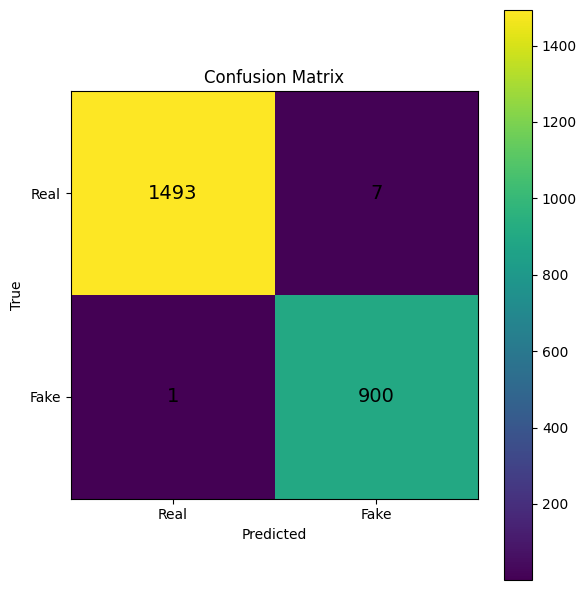

In [11]:
# ============================================================
# Cell 8 : Final Evaluation
# ============================================================

import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Load Best Model
# ------------------------------------------------------------

checkpoint = torch.load(
    MODEL_SAVE_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("="*60)
print("Loaded Best Model")
print("="*60)

print(f"Validation Accuracy : {checkpoint['val_acc']*100:.2f}%")

# ------------------------------------------------------------
# Test Evaluation
# ------------------------------------------------------------

test_loss = 0.0
correct = 0
total = 0

all_labels = []
all_preds = []

with torch.no_grad():

    pbar = tqdm(test_loader)

    for images, labels in pbar:

        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        with autocast():

            outputs = model(images)

            loss = criterion(outputs, labels)

        preds = outputs.argmax(dim=1)

        test_loss += loss.item() * images.size(0)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_labels.extend(
            labels.cpu().numpy()
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

test_loss /= total
test_acc = correct / total

print("\n")
print("="*60)
print("Test Results")
print("="*60)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc*100:.2f}%")

# ------------------------------------------------------------
# Classification Report
# ------------------------------------------------------------

print("\nClassification Report\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Real", "Fake"],
        digits=4
    )
)

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_preds
)

print("\nConfusion Matrix")

print(cm)

# ------------------------------------------------------------
# Plot Confusion Matrix
# ------------------------------------------------------------

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    [0,1],
    ["Real","Fake"]
)

plt.yticks(
    [0,1],
    ["Real","Fake"]
)

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()

plt.show()

In [12]:
# CELL 8: Grad-CAM overlay heatmap and layer activation maps
import matplotlib.pyplot as plt

def get_gradcam(model, image_pil):
    """
    Generates Grad-CAM overlay heatmap and returns early/mid/deep representational layer feature maps.
    """
    model.eval()
    img_resized = image_pil.resize((224, 224))
    tensor = val_transform(img_resized).unsqueeze(0).to(DEVICE)
    
    _acts = {}
    _grads = {}
    
    def fwd_hook(m, inp, out): _acts["map"] = out
    def bwd_hook(m, gin, gout): _grads["map"] = gout[0]
    
    # Hook deep block & features
    target_layer = model.features[-1]
    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)
    
    # Hooks for layers activations
    h_early = model.features[1].register_forward_hook(lambda m, i, o: _acts.update({"early": o}))
    h_mid = model.features[7].register_forward_hook(lambda m, i, o: _acts.update({"mid": o}))
    h_deep = model.features[13].register_forward_hook(lambda m, i, o: _acts.update({"deep": o}))
    
    try:
        model.zero_grad()
        output = model(tensor)
        idx = int(output.argmax())
        output[0, idx].backward()
        
        # Calculate gradients and weights
        weights = _grads["map"].mean(dim=[2, 3], keepdim=True)
        cam = torch.relu((weights * _acts["map"]).sum(dim=1)).squeeze().cpu().detach().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        
        # Plot evaluation results
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        
        # Plot 1: Input image
        axes[0].imshow(img_resized)
        axes[0].set_title("Input Image")
        axes[0].axis("off")
        
        # Plot 2: Early Feature Activations
        early_map = _acts["early"].mean(dim=1).squeeze().cpu().detach().numpy()
        axes[1].imshow(early_map, cmap="jet")
        axes[1].set_title("Early Features (Edges)")
        axes[1].axis("off")
        
        # Plot 3: Intermediate Feature Activations
        mid_map = _acts["mid"].mean(dim=1).squeeze().cpu().detach().numpy()
        axes[2].imshow(mid_map, cmap="jet")
        axes[2].set_title("Intermediate (Shapes)")
        axes[2].axis("off")
        
        # Plot 4: Grad-CAM Saliency Overlay
        axes[3].imshow(img_resized)
        axes[3].imshow(Image.fromarray((cam * 255).astype(np.uint8)).resize((224, 224)), cmap="jet", alpha=0.5)
        axes[3].set_title(f"Grad-CAM (Pred: {'Fake' if idx==1 else 'Real'})")
        axes[3].axis("off")
        
        plt.show()
    finally:
        h1.remove()
        h2.remove()
        h_early.remove()
        h_mid.remove()
        h_deep.remove()

In [13]:
from IPython.display import display
from ipywidgets import FileUpload

uploader = FileUpload(
    accept='image/*',
    multiple=False
)

display(uploader)

print("Upload an image, then run the next cell.")

FileUpload(value=(), accept='image/*', description='Upload')

Upload an image, then run the next cell.


In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

from io import BytesIO
from PIL import Image

from torchvision import transforms
from torchvision.models import mobilenet_v3_large

# ============================================================
# Configuration
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_PATH = "/kaggle/working/mobilenetv3_best.pth"

CLASS_NAMES = [
    "Real",
    "AI Generated"
]

# ============================================================
# Load Model
# ============================================================

model = mobilenet_v3_large(weights=None)

in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, 2)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])

model.to(DEVICE)
model.eval()

print("✅ Model Loaded Successfully")

# ============================================================
# Image Transform
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

# ============================================================
# Check Upload
# ============================================================

if len(uploader.value) == 0:
    print("❌ Please upload an image first.")

else:

    uploaded = uploader.value[0]

    image = Image.open(BytesIO(uploaded.content)).convert("RGB")

    # Display Uploaded Image
    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.title("Uploaded Image")
    plt.axis("off")
    plt.show()

    # ============================================================
    # Prediction
    # ============================================================

    input_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():

        logits = model(input_tensor)

        probabilities = torch.softmax(logits, dim=1)[0]

    prediction = torch.argmax(probabilities).item()

    real_prob = probabilities[0].item() * 100
    fake_prob = probabilities[1].item() * 100

    confidence = probabilities[prediction].item() * 100

    print("="*50)
    print("Prediction Results")
    print("="*50)
    print(f"Predicted Class : {CLASS_NAMES[prediction]}")
    print()
    print(f"Real Probability         : {real_prob:.2f}%")
    print(f"AI Generated Probability : {fake_prob:.2f}%")
    print()
    print(f"Confidence : {confidence:.2f}%")
    print("="*50)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/mobilenetv3_best.pth'